# T7 Feature Selection

Goal: see, step by step, which features the baseline models keep and why. The code is the same one `src/models/train.py` runs before every fit (`src/models/select_features.py`), so what this notebook shows is what training applies.

The four steps run in this order, on the training months only, never on the test months:

1. Drop features with > 40% missing, near-zero variance, or that are a deterministic function of another feature.
2. Drop one of any pair with |correlation| > 0.95, keeping the one with the higher single-feature AUC.
3. Adversarial validation: a classifier tells training rows from test-month rows. A feature with high importance there is drifting and is dropped.
4. Permutation importance on the chosen model: keep the smallest set that stays within 0.002 AUC of the full model.

The candidates include the k-means player segments (`segment_*`, see `docs/player_segments.md`), as in training.

Split: the last cutoff is the test month. The earlier cutoffs are the training months, split by `partyId` into train (85%) and valid (15%), so one player is never in both.

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src" / "models"))
import select_features as sf
from train import NON_FEATURES, TARGET, load_catalog_entry, make_adapter, split_rows
from segments import add_segment_features, fit_segments

DATASET = max((PROJECT_ROOT / "data/processed").glob("train_dataset_*.parquet"), key=lambda p: p.stat().st_mtime)
data = pd.read_parquet(DATASET)
split = split_rows(data)
# Same as train.py: k-means segments fitted on the training months, added as one-hot features.
segment_model = fit_segments(data[split != "test"])
data = add_segment_features(data, segment_model)
train, valid = data[split == "train"], data[split == "valid"]
training_months, test_months = data[split != "test"], data[split == "test"]
candidates = [c for c in data.columns if c not in NON_FEATURES]

print(DATASET.name, data.shape)
pd.crosstab(data["cutoff_date"], split)

train_dataset_64_2026-07-18_2026-07-27_2026-08-05_1791191780.parquet (41328, 37)


col_0,test,train,valid
cutoff_date,,,
2026-07-18,0,10599,1879
2026-07-27,0,12035,2128
2026-08-05,14687,0,0


## Step 1: missing values, near-zero variance, deterministic functions

Our features have no nulls, because `build_features.py` fills them. A filled value is still missing information, so I count it as missing: `tenure_days` when the registration date is unknown, and `rtp_last_7d` when stake is 0. A `days_since_last_*` of 30 is not missing, it means "30 days or more".

Near-zero variance uses caret's rule: the most frequent value is more than 19 times as common as the second one, and less than 10% of the values are distinct.

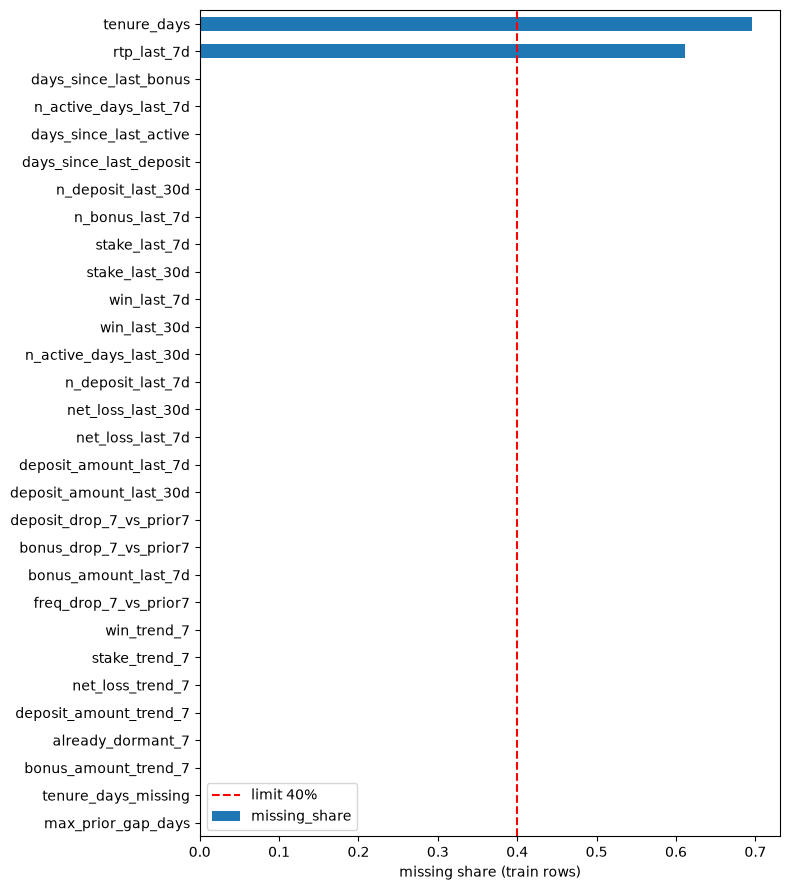

,missing_share,top_value_ratio,unique_share,near_zero_variance,single_feature_auc
tenure_days,0.696,90.810,0.063,True,0.570
rtp_last_7d,0.611,1.170,0.374,False,0.548
days_since_last_bonus,0.000,1.240,0.001,False,0.670
n_active_days_last_7d,0.000,1.591,0.000,False,0.741
days_since_last_active,0.000,1.733,0.001,False,0.738
days_since_last_deposit,0.000,3.039,0.001,False,0.761
n_deposit_last_30d,0.000,1.643,0.001,False,0.793
n_bonus_last_7d,0.000,1.244,0.000,False,0.695
stake_last_7d,0.000,294.255,0.372,False,0.710
stake_last_30d,0.000,92.643,0.549,False,0.792


In [14]:
auc = {f: sf.single_feature_auc(train[f], train[TARGET]) for f in candidates}

def top_value_ratio(s):
    counts = s.value_counts()
    return counts.iloc[0] / counts.iloc[1] if len(counts) > 1 else np.inf

step1_table = pd.DataFrame({
    "missing_share": {f: sf._missing_share(train, f) for f in candidates},
    "top_value_ratio": {f: top_value_ratio(train[f]) for f in candidates},
    "unique_share": {f: train[f].nunique() / len(train) for f in candidates},
    "near_zero_variance": {f: sf._near_zero_variance(train[f]) for f in candidates},
    "single_feature_auc": auc,
}).sort_values("missing_share", ascending=False)

ax = step1_table["missing_share"].plot.barh(figsize=(8, 9), color="tab:blue")
ax.axvline(sf.MAX_MISSING_SHARE, color="red", linestyle="--", label=f"limit {sf.MAX_MISSING_SHARE:.0%}")
ax.invert_yaxis(); ax.set_xlabel("missing share (train rows)"); ax.legend(); plt.tight_layout(); plt.show()
step1_table.round(3)

In [15]:
after1, dropped1 = sf._step1(train, candidates, auc)
print(f"{len(candidates)} -> {len(after1)} features")
pd.DataFrame(dropped1)

30 -> 26 features


,feature,step,reason
0,deposit_amount_last_7d,1,near-zero variance
1,tenure_days,1,70% missing (imputed values count)
2,rtp_last_7d,1,61% missing (imputed values count)
3,already_dormant_7,1,deterministic function of days_since_last_active


## Step 2: pairs with |correlation| > 0.95

Pearson correlation on the training rows. For each pair over the limit, the feature with the lower single-feature AUC goes.

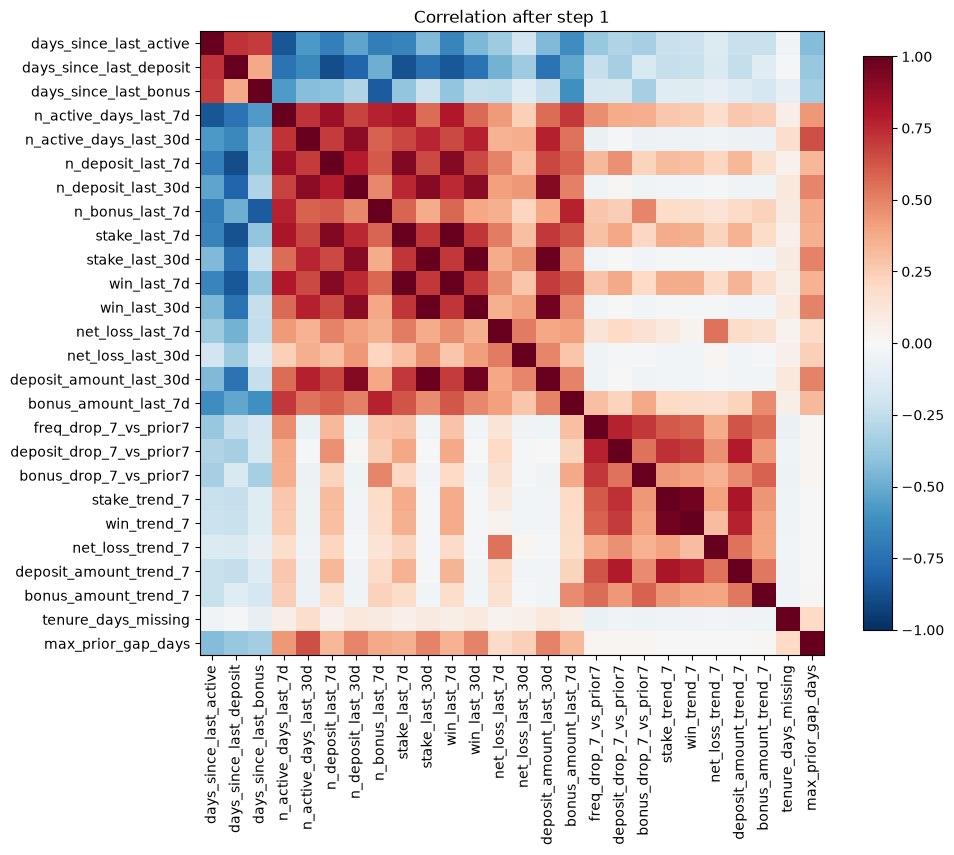

,,abs_corr
stake_last_30d,win_last_30d,0.993130
stake_last_7d,win_last_7d,0.992984
stake_last_30d,deposit_amount_last_30d,0.979903
stake_trend_7,win_trend_7,0.967953
win_last_30d,deposit_amount_last_30d,0.966417


In [16]:
corr = train[after1].corr()
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(after1)), after1, rotation=90); ax.set_yticks(range(len(after1)), after1)
fig.colorbar(im, ax=ax, shrink=0.8); ax.set_title("Correlation after step 1"); plt.tight_layout(); plt.show()

high = corr.abs().where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
high[high > sf.MAX_ABS_CORR].sort_values(ascending=False).rename("abs_corr").to_frame()

In [17]:
after2, dropped2 = sf._step2(train, after1, auc)
print(f"{len(after1)} -> {len(after2)} features")
pd.DataFrame(dropped2)

26 -> 22 features


,feature,step,reason
0,win_last_30d,2,|corr| 0.993 with stake_last_30d (AUC 0.788 < ...
1,win_last_7d,2,|corr| 0.993 with stake_last_7d (AUC 0.705 < 0...
2,deposit_amount_last_30d,2,|corr| 0.980 with stake_last_30d (AUC 0.789 < ...
3,stake_trend_7,2,|corr| 0.968 with win_trend_7 (AUC 0.509 < 0.509)


## Step 3: adversarial validation

A LightGBM classifier tries to tell training-month rows (label 0) from test-month rows (label 1), with 5-fold out-of-fold predictions. AUC near 0.5 means the two periods look the same.

While the AUC is 0.70 or more, every feature with more than 10% of the adversarial importance is dropped and the check runs again. Below 0.70 the drift is mild, so the features stay (0.60 removed the strongest signals in a test run).

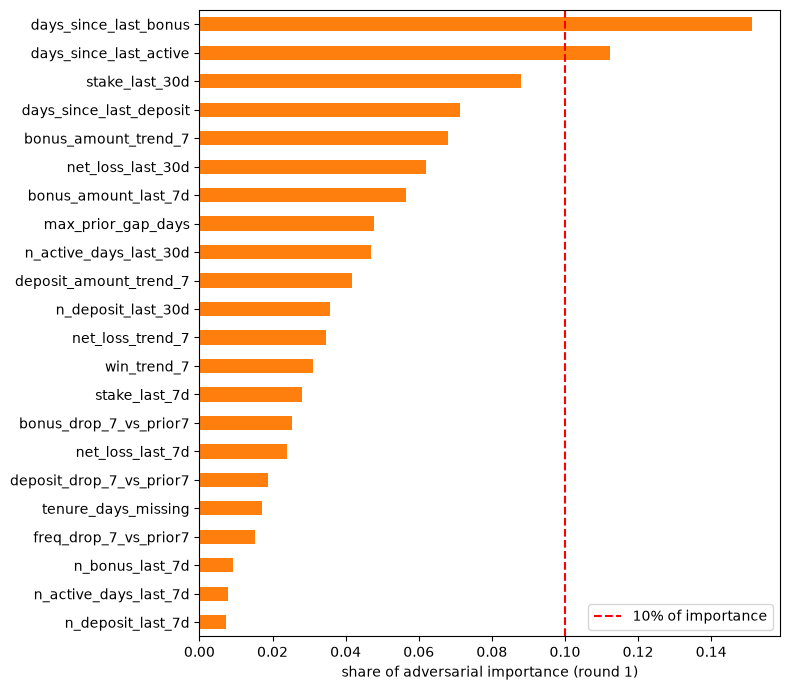

,round,n_features,adversarial_auc,dropped
0,1,22,0.7236,"[days_since_last_active, days_since_last_bonus]"
1,2,20,0.6599,[]


In [18]:
kept, rounds = list(after2), []
for round_ in range(1, sf.MAX_ADV_ROUNDS + 1):
    adv_auc, share = sf.adversarial_validation(training_months, test_months, kept)
    drifting = list(share[share > sf.ADV_IMPORTANCE_SHARE].index)
    rounds.append({"round": round_, "n_features": len(kept), "adversarial_auc": round(adv_auc, 4),
                   "dropped": drifting if adv_auc >= sf.ADV_AUC_THRESHOLD else []})
    if round_ == 1:
        first_share = share
    if adv_auc < sf.ADV_AUC_THRESHOLD or not drifting:
        break
    kept = [f for f in kept if f not in drifting]

ax = first_share.sort_values().plot.barh(figsize=(8, 7), color="tab:orange")
ax.axvline(sf.ADV_IMPORTANCE_SHARE, color="red", linestyle="--", label=f"{sf.ADV_IMPORTANCE_SHARE:.0%} of importance")
ax.set_xlabel("share of adversarial importance (round 1)"); ax.legend(); plt.tight_layout(); plt.show()
pd.DataFrame(rounds)

In [19]:
after3, dropped3, adv_auc, adv_auc_after, adv_share = sf._step3(training_months, test_months, after2)
print(f"{len(after2)} -> {len(after3)} features | adversarial AUC {adv_auc:.3f} -> {adv_auc_after:.3f}")
pd.DataFrame(dropped3)

22 -> 20 features | adversarial AUC 0.724 -> 0.660


,feature,step,reason
0,days_since_last_active,3,drifting: 11% of adversarial importance (AUC 0...
1,days_since_last_bonus,3,drifting: 15% of adversarial importance (AUC 0...


## Step 4: permutation importance on the chosen model

The chosen model comes from the catalog with its default parameters (LightGBM: binary log-loss with `scale_pos_weight`, early stopping on AUC and log-loss of the valid rows). I fit it on the train rows with every feature left, then shuffle one feature at a time on the valid rows and measure how much the AUC drops. Then I add features in that order and keep the smallest set whose valid AUC is within 0.002 of the full model.

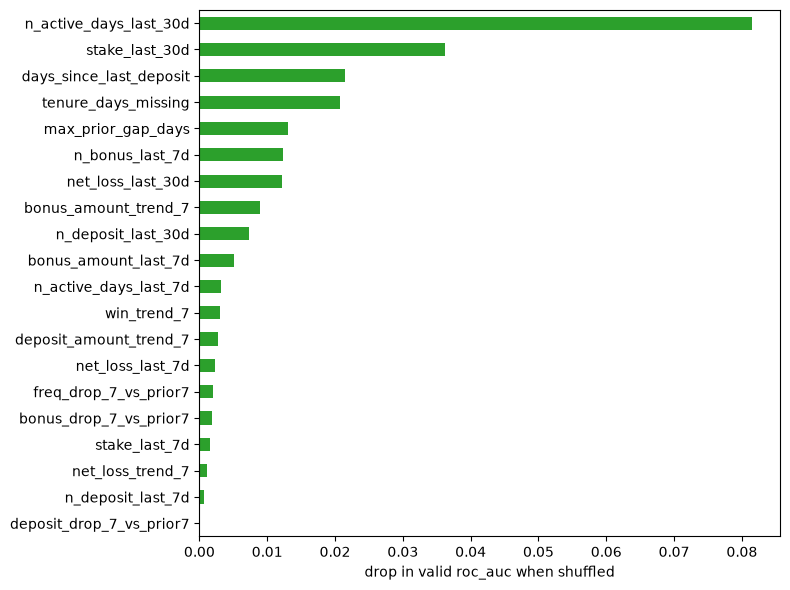

full model, 20 features: valid roc_auc = 0.8786


In [20]:
MODEL_ID = "lightgbm_classifier"
entry, _, _ = load_catalog_entry(MODEL_ID)
adapter = make_adapter(entry, None, train, valid)

full_model = adapter.fit(after3)
full_score = adapter.score(full_model, valid, after3)
importance = sf.permutation_importance(adapter, full_model, valid, after3)

ax = importance.sort_values().plot.barh(figsize=(8, 6), color="tab:green")
ax.set_xlabel(f"drop in valid {adapter.metric} when shuffled"); plt.tight_layout(); plt.show()
print(f"full model, {len(after3)} features: valid {adapter.metric} = {full_score:.4f}")

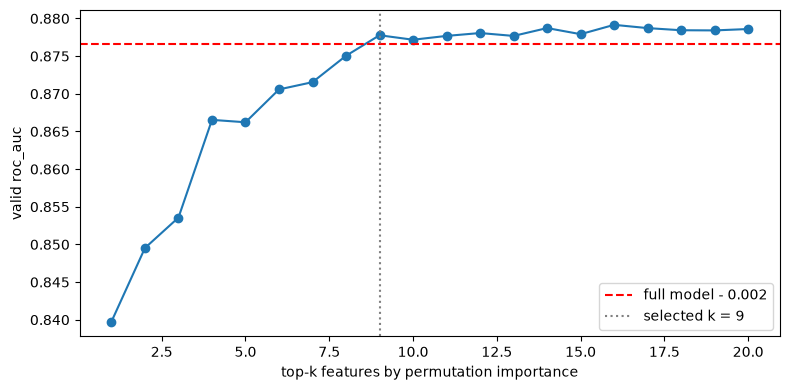

selected: ['n_active_days_last_30d', 'stake_last_30d', 'days_since_last_deposit', 'tenure_days_missing', 'max_prior_gap_days', 'n_bonus_last_7d', 'net_loss_last_30d', 'bonus_amount_trend_7', 'n_deposit_last_30d']


In [21]:
ranked = list(importance.index)
curve = pd.Series({k: adapter.score(adapter.fit(ranked[:k]), valid, ranked[:k]) for k in range(1, len(ranked) + 1)})
best_k = int(curve[curve >= full_score - sf.MAX_METRIC_LOSS].index.min())

ax = curve.plot(marker="o", figsize=(8, 4))
ax.axhline(full_score - sf.MAX_METRIC_LOSS, color="red", linestyle="--", label="full model - 0.002")
ax.axvline(best_k, color="grey", linestyle=":", label=f"selected k = {best_k}")
ax.set_xlabel("top-k features by permutation importance"); ax.set_ylabel(f"valid {adapter.metric}"); ax.legend()
plt.tight_layout(); plt.show()
print("selected:", ranked[:best_k])

## Final result

The same call `train.py` makes. The report says, for every feature, in which step it was dropped and why. MLflow saves it as `feature_selection.csv` in each training run.

In [22]:
selected, report, summary = sf.select_features(data, split, candidates, adapter, TARGET)
print(summary)
report

{'n_features_candidate': 30, 'n_dropped_step1': 4, 'n_dropped_step2': 4, 'n_dropped_step3': 2, 'n_dropped_step4': 11, 'n_features_selected': 9, 'adversarial_auc': 0.7236262201851817, 'adversarial_auc_after_step3': 0.6598947413555392, 'selection_full_valid_roc_auc': 0.8786065110676424, 'selection_selected_valid_roc_auc': 0.8777713078099767}


,feature,single_feature_auc,adversarial_importance,permutation_importance,step,reason,selected
0,n_active_days_last_30d,0.8335,0.0468,0.08154,NaN,NaN,True
1,stake_last_30d,0.7916,0.0880,0.03615,NaN,NaN,True
2,days_since_last_deposit,0.7607,0.0714,0.02152,NaN,NaN,True
3,tenure_days_missing,0.6022,0.0171,0.02075,NaN,NaN,True
4,max_prior_gap_days,0.7997,0.0477,0.01300,NaN,NaN,True
5,n_bonus_last_7d,0.6949,0.0092,0.01235,NaN,NaN,True
6,net_loss_last_30d,0.6858,0.0621,0.01212,NaN,NaN,True
7,bonus_amount_trend_7,0.5001,0.0680,0.00894,NaN,NaN,True
8,n_deposit_last_30d,0.7932,0.0357,0.00736,NaN,NaN,True
9,deposit_amount_last_7d,0.7042,NaN,NaN,1.0,near-zero variance,False


## Cox PH (only when the dataset has the survival columns)

Steps 1 to 3 do not depend on the model. Step 4 uses the Cox model and its concordance index (c-index) instead of AUC.

In [23]:
if {"duration_days", "event_observed"} <= set(data.columns):
    cox_entry, _, _ = load_catalog_entry("cox_ph")
    cox_adapter = make_adapter(cox_entry, None, train, valid)
    cox_selected, cox_report, cox_summary = sf.select_features(data, split, candidates, cox_adapter, TARGET)
    print(cox_summary)
    display(cox_report)
else:
    print("No survival columns yet: rebuild with `make labels dataset`.")

{'n_features_candidate': 30, 'n_dropped_step1': 4, 'n_dropped_step2': 4, 'n_dropped_step3': 2, 'n_dropped_step4': 16, 'n_features_selected': 4, 'adversarial_auc': 0.7236262201851817, 'adversarial_auc_after_step3': 0.6598947413555392, 'selection_full_valid_c_index': np.float64(0.8494743341343858), 'selection_selected_valid_c_index': np.float64(0.8486509415655153)}


,feature,single_feature_auc,adversarial_importance,permutation_importance,step,reason,selected
0,max_prior_gap_days,0.7997,0.0477,0.02991,NaN,NaN,True
1,n_active_days_last_30d,0.8335,0.0468,0.01582,NaN,NaN,True
2,tenure_days_missing,0.6022,0.0171,0.01514,NaN,NaN,True
3,stake_last_30d,0.7916,0.0880,0.00693,NaN,NaN,True
4,deposit_amount_last_7d,0.7042,NaN,NaN,1.0,near-zero variance,False
5,already_dormant_7,0.6800,NaN,NaN,1.0,deterministic function of days_since_last_active,False
6,tenure_days,0.5699,NaN,NaN,1.0,70% missing (imputed values count),False
7,rtp_last_7d,0.5479,NaN,NaN,1.0,61% missing (imputed values count),False
8,win_last_7d,0.7053,NaN,NaN,2.0,|corr| 0.993 with stake_last_7d (AUC 0.705 < 0...,False
9,win_last_30d,0.7883,NaN,NaN,2.0,|corr| 0.993 with stake_last_30d (AUC 0.788 < ...,False
